In [ ]:
# Reducir el dataset con PCA, tme, UMAP (hay que bajarlo a dos
# dimensiones), plotearlo, método de elbow y silouete, KMeans
# https://www.kaggle.com/datasets/thedevastator/spotify-tracks-genre-dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [3]:
path='/content/drive/MyDrive/EDEM IA/IA_predictiva/Clustering/Entregable/genres_v2.csv'
df=pd.read_csv(path)

/tmp/ipython-input-4148699147.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path)


In [4]:
print(df.head(10))

   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.831   0.814    2    -7.364     1       0.4200        0.0598   
1         0.719   0.493    8    -7.230     1       0.0794        0.4010   
2         0.850   0.893    5    -4.783     1       0.0623        0.0138   
3         0.476   0.781    0    -4.710     1       0.1030        0.0237   
4         0.798   0.624    2    -7.668     1       0.2930        0.2170   
5         0.721   0.568    0   -11.295     1       0.4140        0.0452   
6         0.718   0.668    8    -4.162     1       0.1370        0.0254   
7         0.694   0.711    8    -5.525     1       0.2210        0.0397   
8         0.774   0.751    1    -2.445     1       0.1980        0.0614   
9         0.893   0.907   11   -10.406     1       0.3670        0.1520   

   instrumentalness  liveness  valence  ...                      id  \
0          0.013400    0.0556   0.3890  ...  2Vc6NJ9PW9gD9q343XFRKx   
1          0.000000    0.1180   

In [5]:
print(df.dtypes)


danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
type                 object
id                   object
uri                  object
track_href           object
analysis_url         object
duration_ms           int64
time_signature        int64
genre                object
song_name            object
Unnamed: 0          float64
title                object
dtype: object


In [6]:
# Contar valores únicos por columna
valores_unicos = df.nunique()

# Mostrar resultados
print(valores_unicos)

danceability          890
energy                917
key                    12
loudness            11654
mode                    2
speechiness          1447
acousticness         4602
instrumentalness     4757
liveness             1695
valence              1674
tempo               15606
type                    1
id                  35877
uri                 35877
track_href          35877
analysis_url        35877
duration_ms         26261
time_signature          4
genre                  15
song_name           15439
Unnamed: 0          20780
title                 132
dtype: int64


In [7]:
# Vamos a eliminar las de tipo categoría y quedarnos solo con las numéricas
df_num = df.select_dtypes(include=['float64'])
print(df_num.dtypes)

danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
Unnamed: 0          float64
dtype: object


In [8]:
# Borramos la columna de Unnamed porque no aporta ningún valor
df_num = df_num.drop('Unnamed: 0', axis=1)




In [9]:
# Comprobamos si en nuestro dataset hay algúna NA
total_nans = df_num.isnull().sum().sum()
print("Total de valores NaN en el DataFrame:", total_nans)

filas_con_nan = df_num.isnull().any(axis=1).sum()
print("Número de filas con al menos un NaN:", filas_con_nan)

Total de valores NaN en el DataFrame: 0
Número de filas con al menos un NaN: 0


Ahora voy a crear nuevas variables.

In [10]:
df_num['dance_energy'] = df_num['danceability'] * df_num['energy']
df_num['total_activity'] = df_num['danceability'] + df_num['energy'] + df_num['valence']
df_num['vocal_instrumental_balance'] = df_num['speechiness'] - df_num['instrumentalness']

In [11]:
print(df_num.columns)

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'dance_energy',
       'total_activity', 'vocal_instrumental_balance'],
      dtype='object')


In [12]:
# Ahora normalizamos

# Instanciamos el scaler
scaler = StandardScaler()

# Ajustamos y transformamos los datos
df_num_scaled = scaler.fit_transform(df_num)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
df_num_scaled = pd.DataFrame(df_num_scaled, columns=df_num.columns)

# Revisar
print(df_num_scaled.head())


   danceability    energy  loudness  speechiness  acousticness  \
0      1.223608  0.280079 -0.305514     2.246552     -0.212853   
1      0.508480 -1.466185 -0.259954    -0.453057      1.784518   
2      1.344924  0.709845  0.572039    -0.588592     -0.482135   
3     -1.043093  0.100557  0.596860    -0.266002     -0.424181   
4      1.012900 -0.753535 -0.408876     1.239945      0.707390   

   instrumentalness  liveness   valence     tempo  dance_energy  \
0         -0.727231 -0.902637  0.136790  0.398876      1.422447   
1         -0.763370 -0.547231 -0.999586 -1.358564     -0.888082   
2         -0.763359  0.899456 -1.363655  2.959861      2.015324   
3         -0.763370 -0.570013 -0.780887  1.655485     -0.764011   
4         -0.763370 -0.273841  1.003008  0.021554      0.141608   

   total_activity  vocal_instrumental_balance  
0        0.794099                    1.270310  
1       -1.221328                    0.518809  
2        0.066755                    0.479525  
3       

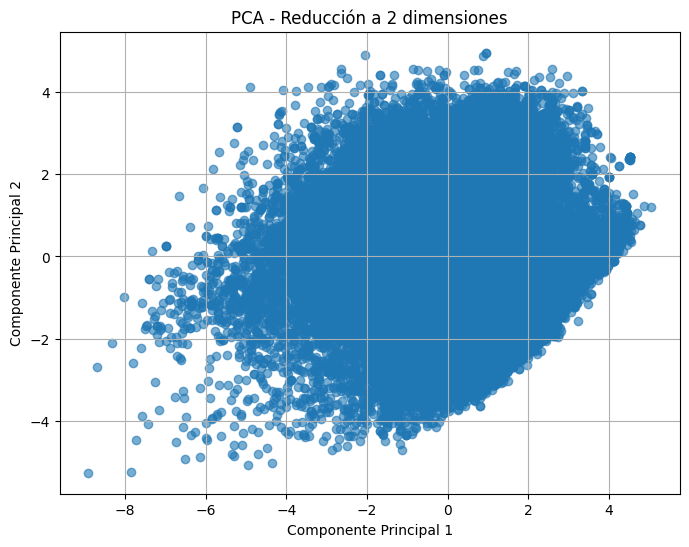

In [13]:
# Instanciamos PCA para 2 componentes
pca = PCA(n_components=2)

# Ajustamos PCA y transformamos los datos
X_pca = pca.fit_transform(df_num_scaled)

# Convertir a DataFrame para mayor comodidad
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])


# Graficar
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.6)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Reducción a 2 dimensiones')
plt.grid(True)
plt.show()



 La gran densidad de puntos alrededor del centro significa que muchos datos son similares en estas combinaciones de características. No se puede distinguir ningún cluster.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


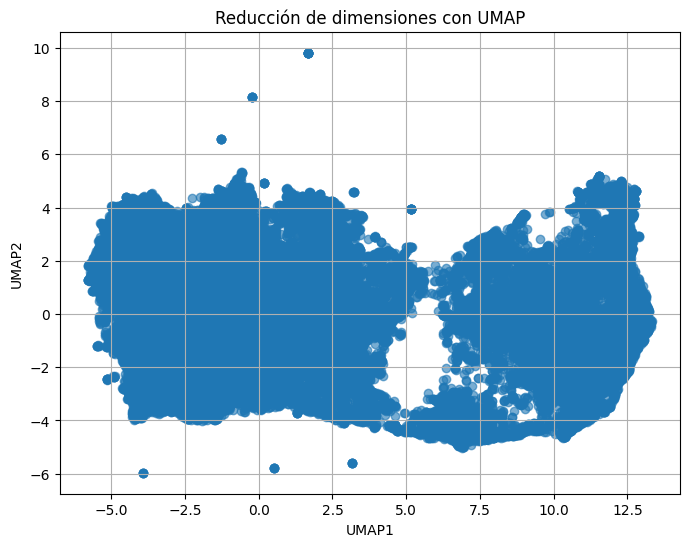

In [14]:
# Ahora con UMAP

# Suponiendo que tus datos normalizados están en df_num_scaled
reducer = umap.UMAP(n_components=2, random_state=42)

# Reducimos los datos a 2 dimensiones
X_umap = reducer.fit_transform(df_num_scaled)

# Convertir a DataFrame para mayor comodidad
df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])

# Graficar
plt.figure(figsize=(8,6))
plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], alpha=0.6)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Reducción de dimensiones con UMAP')
plt.grid(True)
plt.show()


A diferencia del gráfico anterior, aquí se pueden diferenciar tres clusters, el predominante donde se agrupan la mayoría de las canciones es el de la izquierda, y a la derecha se pueden observar dos más pequeños. También se pueden ver outliers al igual que con el PCA aunque en menor cantidad, por lo que los grupos son más compactos. Como el tiempo de ejecución mediante el t-SNE resultó excesivo (más de 20m), voy a optar por hacer los clusters con UMAP y el algoritmo de Kmeans.

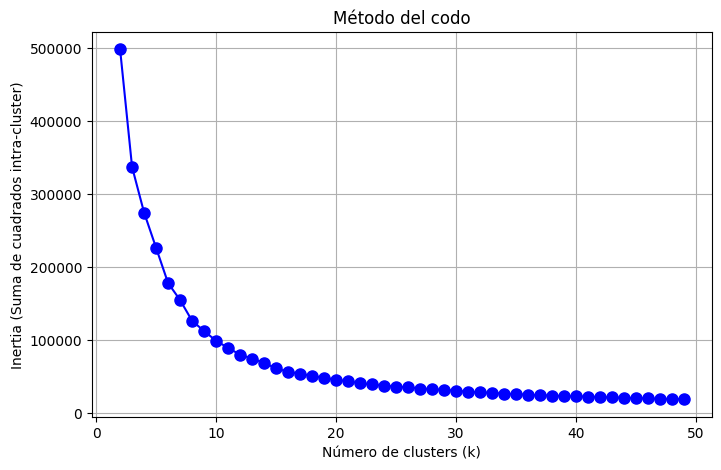

In [ ]:
# Método del codo
inertia = []
K_range = range(2, 50)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_umap)
    inertia.append(kmeans.inertia_)

# Graficamos el codo
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia (Suma de cuadrados intra-cluster)')
plt.title('Método del codo')
plt.grid(True)
plt.show()

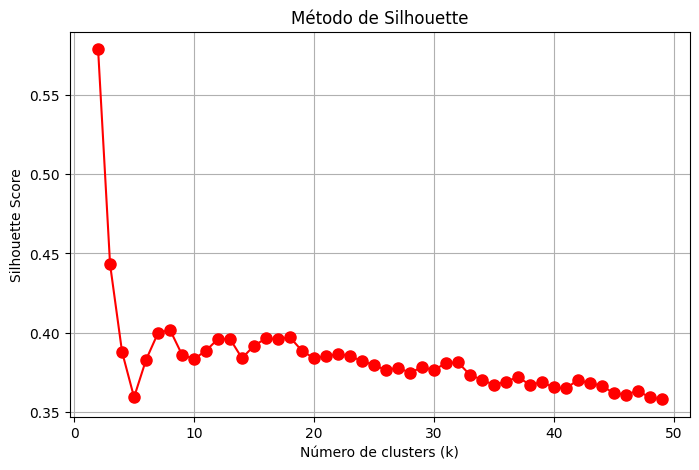

In [ ]:
# Método de Silhouette
silhouette_avg = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_umap)
    score = silhouette_score(df_umap, cluster_labels)
    silhouette_avg.append(score)

# Graficamos silhouette
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_avg, 'ro-', markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de Silhouette')
plt.grid(True)
plt.show()

De acuerdo con estos dos gráficos, he decido crear 40 clusters, ya que la reducción marginal en este número ya es bastante baja tanto en el método del codo como el de Silhouette.

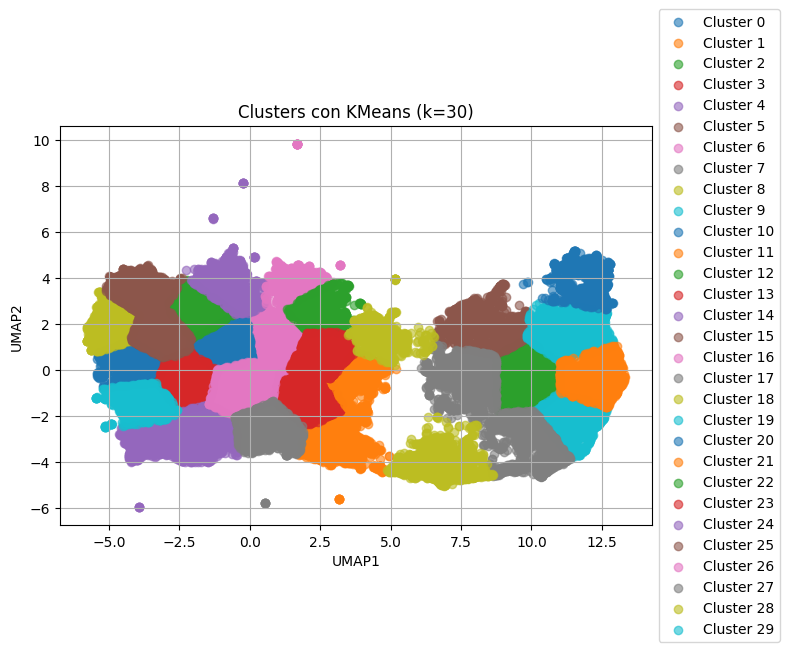

In [17]:
# Aplicación del Kmeans
k_opt = 30
kmeans_final = KMeans(n_clusters=k_opt, random_state=42)
df_umap['Cluster'] = kmeans_final.fit_predict(df_umap)

# 4. Graficar los clusters
plt.figure(figsize=(8,6))
for cluster in range(k_opt):
    plt.scatter(
        df_umap[df_umap['Cluster']==cluster]['UMAP1'],
        df_umap[df_umap['Cluster']==cluster]['UMAP2'],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title(f'Clusters con KMeans (k={k_opt})')

# Leyenda a la derecha
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid(True)
plt.tight_layout()
plt.show()



El gráfico muestra cómo los datos se agrupan en 30 grupos diferentes todas las canciones de nuestro dataset, cada uno representado por un color. Las zonas de un mismo color indican puntos con características similares, mientras que los cambios de color señalan diferencias entre grupos. En conjunto, sirve para ver cómo se organiza y distribuye la información. Esto puede ayudar a organizar música según su estilo o género, facilitando así las recomendaciones personalizadas o nuevas sugerencias.
